In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

C:\Users\Krishna\anaconda3\envs\ai_lab\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
mask_tr = (y_train == 0) | (y_train == 1)
mask_te = (y_test  == 0) | (y_test  == 1)
X_tr, y_tr = X_train[mask_tr], y_train[mask_tr]
X_te, y_te = X_test[mask_te],  y_test[mask_te]

In [5]:
X_tr = X_tr.reshape(-1, 784).astype('float32') / 255.0
X_te = X_te.reshape(-1, 784).astype('float32') / 255.0

In [6]:
perceptron = keras.Sequential([
    keras.layers.Dense(1, activation='sigmoid', input_shape=(784,))
])
perceptron.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
h1 = perceptron.fit(X_tr, y_tr, epochs=10, validation_data=(X_te, y_te), verbose=0)
print("Perceptron test acc:", perceptron.evaluate(X_te, y_te, verbose=0)[1])

C:\Users\Krishna\anaconda3\envs\ai_lab\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Perceptron test acc: 0.9990543723106384


In [7]:
mlp = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h2 = mlp.fit(X_tr, y_tr, epochs=15, validation_data=(X_te, y_te), verbose=0)
print("MLP test acc:", mlp.evaluate(X_te, y_te, verbose=0)[1])

MLP test acc: 0.9995272159576416


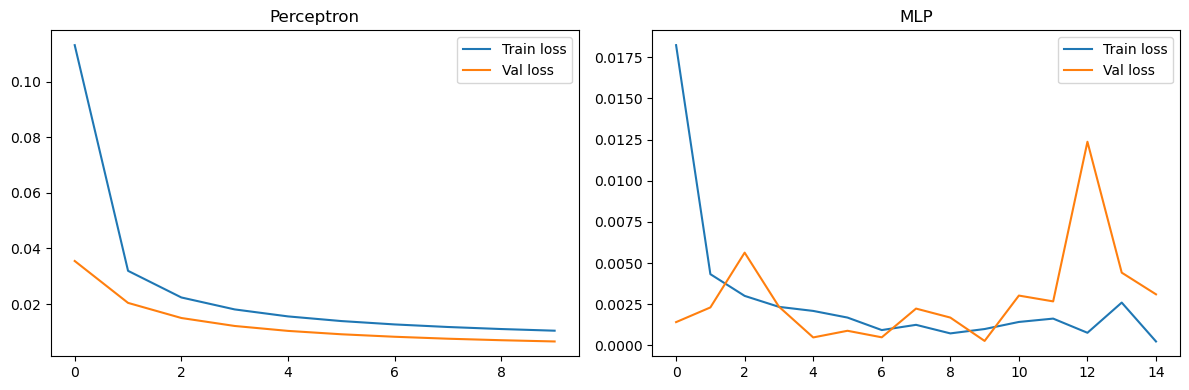

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h, title in zip(axes, [h1, h2], ['Perceptron', 'MLP']):
    ax.plot(h.history['loss'], label='Train loss')
    ax.plot(h.history['val_loss'], label='Val loss')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()